# Stock Price Prediction — Model Building & Evaluation

Seven regression models are trained on engineered AAPL features to predict the
next day's closing price. We use a strictly chronological train/test split,
TimeSeriesSplit cross-validation, and GridSearchCV tuning — all appropriate for
time-series data where future information must never leak into training.

## 1. Imports & Load Cleaned Data

We load the pre-engineered feature matrix produced by notebook 02 and import the
evaluation helpers from `utils.py`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings('ignore')

from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score

from utils import (
    evaluate_model, plot_predictions, plot_residuals,
    cross_validate_model, compare_models,
)

sns.set_style('whitegrid')
%matplotlib inline

df = pd.read_csv('data/aapl_features.csv', parse_dates=['date'])
print('Shape:', df.shape)
df.tail()

Shape: (1238, 20)


,date,open,high,low,close,volume,Name,lag_1,lag_2,lag_3,lag_5,ma_5,ma_10,ma_20,std_5,daily_return,volume_change,high_low_range,open_close_range,next_close
1233,2018-01-31,166.870,168.4417,166.50,167.43,32478930,AAPL,166.97,167.96,171.51,174.22,170.354,174.263,174.3340,2.917041,0.002755,-0.294675,1.9417,-0.560,167.78
1234,2018-02-01,167.165,168.6200,166.76,167.78,47230787,AAPL,167.43,166.97,167.96,171.11,168.996,173.096,174.0925,2.145898,0.002090,0.454198,1.8600,-0.615,160.50
1235,2018-02-02,166.000,166.8000,160.10,160.50,86593825,AAPL,167.78,167.43,166.97,171.51,168.330,171.948,173.8700,1.817374,-0.043390,0.833419,6.7000,5.500,156.49
1236,2018-02-05,159.100,163.8800,156.00,156.49,72738522,AAPL,160.50,167.78,167.43,167.96,166.128,170.152,173.2435,3.168749,-0.024984,-0.160003,7.8800,2.610,163.03
1237,2018-02-06,154.830,163.7200,154.00,163.03,68243838,AAPL,156.49,160.50,167.78,166.97,163.834,168.101,172.3180,5.083958,0.041792,-0.061792,9.7200,-8.200,159.54


## 2. Feature Matrix, Chronological Split & Scaling

For time-series data, shuffling the train/test split would leak future information
into the training set and inflate performance metrics. We therefore use the first
80 % of rows (sorted by date) as training data and the last 20 % as the test set.

The `StandardScaler` is **fit on the training set only** and then applied to both
sets — a critical step to prevent target leakage from the test distribution.

In [2]:
feature_cols = [
    'open', 'high', 'low', 'close', 'volume',
    'lag_1', 'lag_2', 'lag_3', 'lag_5',
    'ma_5', 'ma_10', 'ma_20', 'std_5',
    'daily_return', 'volume_change',
    'high_low_range', 'open_close_range',
]
target_col = 'next_close'

X = df[feature_cols].values
y = df[target_col].values

split_idx = int(len(df) * 0.80)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Total samples : {len(df)}')
print(f'Train samples : {len(X_train)}  ({X_train.shape[1]} features)')
print(f'Test  samples : {len(X_test)}')
print(f'Train period  : {df["date"].iloc[0].date()} → {df["date"].iloc[split_idx-1].date()}')
print(f'Test  period  : {df["date"].iloc[split_idx].date()} → {df["date"].iloc[-1].date()}')

Total samples : 1238
Train samples : 990  (17 features)
Test  samples : 248
Train period  : 2013-03-11 → 2017-02-10
Test  period  : 2017-02-13 → 2018-02-06


## 3. Train Seven Regressors

We benchmark seven standard scikit-learn regressors. For each model we: (1) fit on
training data, (2) predict on the test set, (3) call `evaluate_model()` to print
metrics, and (4) plot the predicted vs actual price line to visually inspect
tracking quality.

In [3]:
results = []
models  = {}  # name → (input_type, fitted_model)

### 3a. Linear Regression

A simple baseline: ordinary least squares fit to all scaled features.


  Linear Regression
  MAE   : 1.3316
  RMSE  : 1.8969
  R2    : 0.9751
  MAPE  : 0.0085


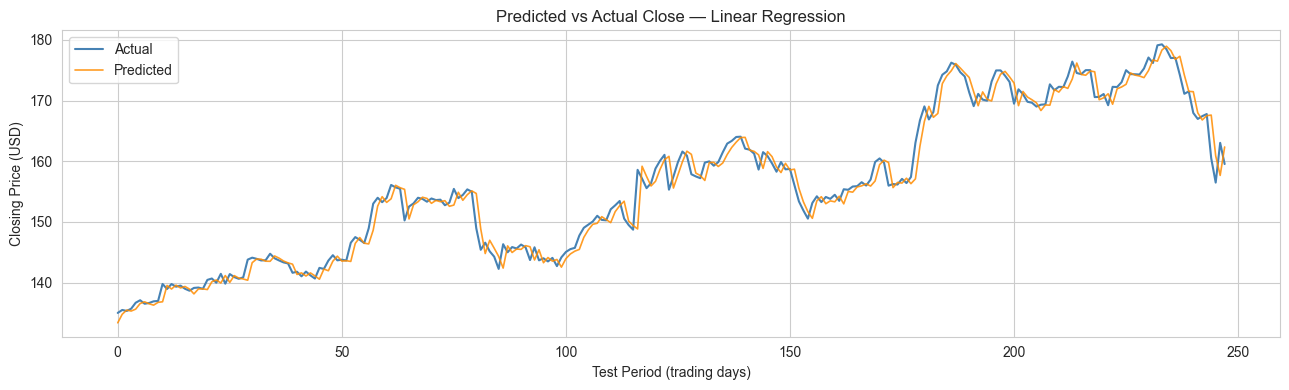

In [4]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
results.append(evaluate_model('Linear Regression', y_test, y_pred_lr))
models['Linear Regression'] = ('scaled', lr)
plot_predictions(y_test, y_pred_lr, 'Linear Regression'); plt.show()

### 3b. Ridge Regression

Ridge adds L2 regularisation, which shrinks coefficients and reduces the impact of
multicollinearity among the highly correlated lag and moving-average features.


  Ridge
  MAE   : 1.3316
  RMSE  : 1.9018
  R2    : 0.9750
  MAPE  : 0.0085


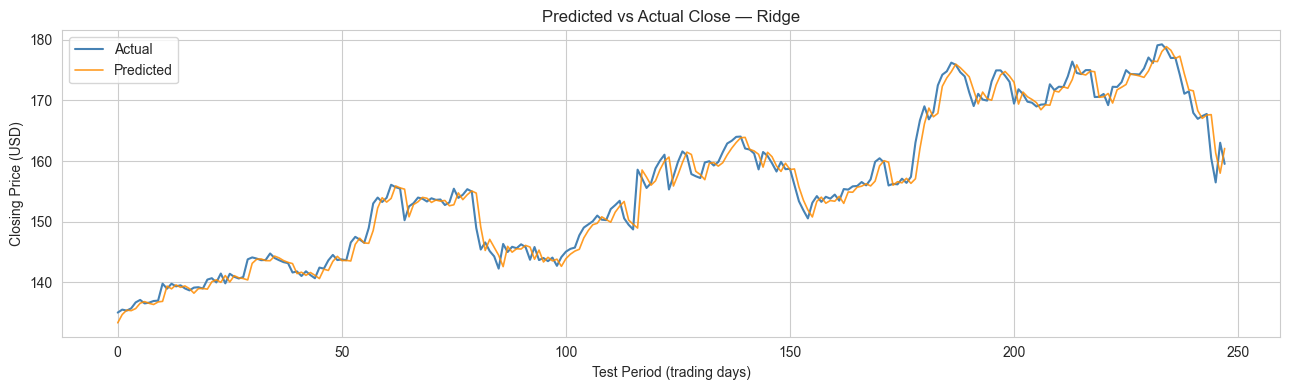

In [5]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
y_pred_ridge = ridge.predict(X_test_scaled)
results.append(evaluate_model('Ridge', y_test, y_pred_ridge))
models['Ridge'] = ('scaled', ridge)
plot_predictions(y_test, y_pred_ridge, 'Ridge'); plt.show()

### 3c. Lasso Regression

Lasso uses L1 regularisation, which can zero-out irrelevant features entirely —
effectively performing automatic feature selection.


  Lasso
  MAE   : 1.3310
  RMSE  : 1.9027
  R2    : 0.9750
  MAPE  : 0.0085


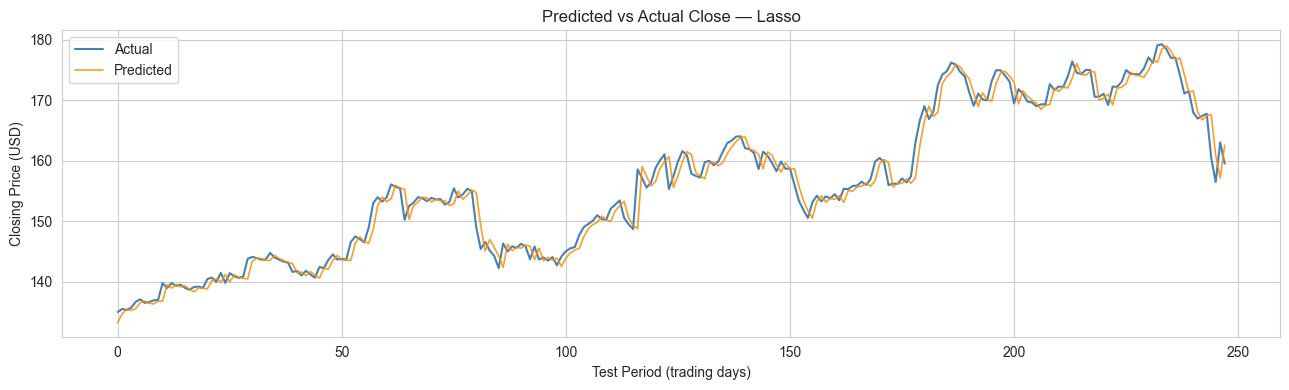

In [6]:
lasso = Lasso(alpha=0.01, max_iter=10000)
lasso.fit(X_train_scaled, y_train)
y_pred_lasso = lasso.predict(X_test_scaled)
results.append(evaluate_model('Lasso', y_test, y_pred_lasso))
models['Lasso'] = ('scaled', lasso)
plot_predictions(y_test, y_pred_lasso, 'Lasso'); plt.show()

### 3d. Decision Tree

A shallow decision tree (max depth = 10) can capture non-linear breakpoints in the
feature space, though it is prone to overfitting on time-series data.


  Decision Tree
  MAE   : 27.9332
  RMSE  : 30.4578
  R2    : -5.4165
  MAPE  : 0.1742


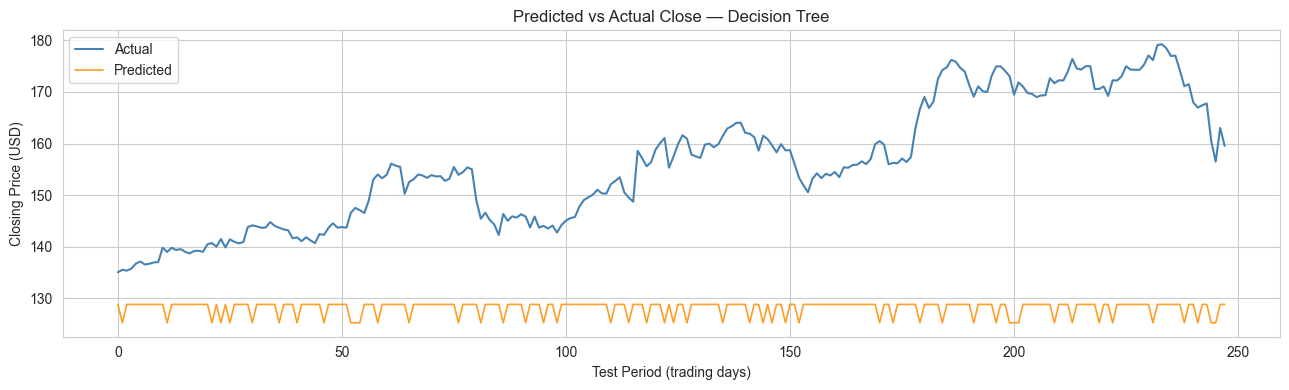

In [7]:
dt = DecisionTreeRegressor(max_depth=10, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
results.append(evaluate_model('Decision Tree', y_test, y_pred_dt))
models['Decision Tree'] = ('raw', dt)
plot_predictions(y_test, y_pred_dt, 'Decision Tree'); plt.show()

### 3e. Random Forest

Random Forest averages 200 decision trees trained on bootstrap samples. The
ensemble smooths out individual tree variance and typically generalises better
than a single tree.


  Random Forest
  MAE   : 26.2633
  RMSE  : 28.9213
  R2    : -4.7854
  MAPE  : 0.1634


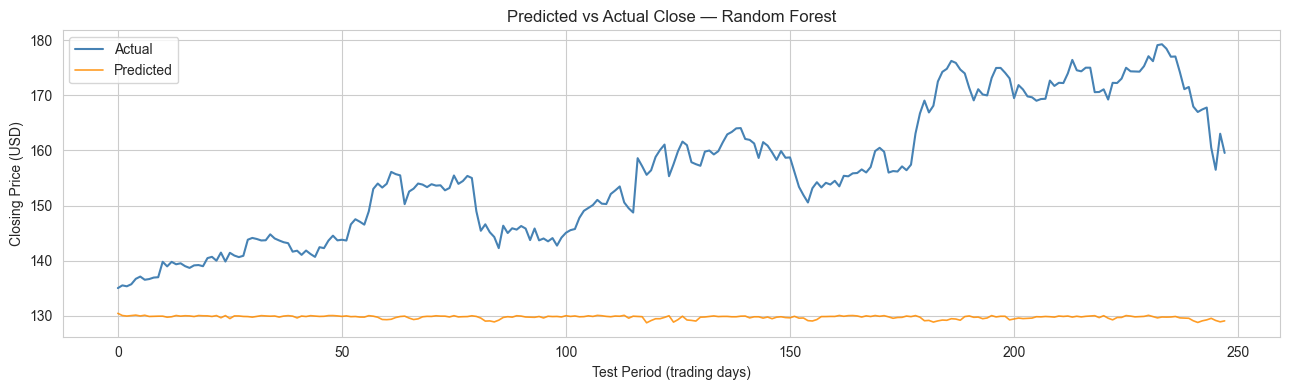

In [8]:
rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
results.append(evaluate_model('Random Forest', y_test, y_pred_rf))
models['Random Forest'] = ('raw', rf)
plot_predictions(y_test, y_pred_rf, 'Random Forest'); plt.show()

### 3f. K-Nearest Neighbours (K optimised)

KNN predicts by averaging the K closest training examples. We sweep K from 3 to 20
and pick the value that maximises test-set R².

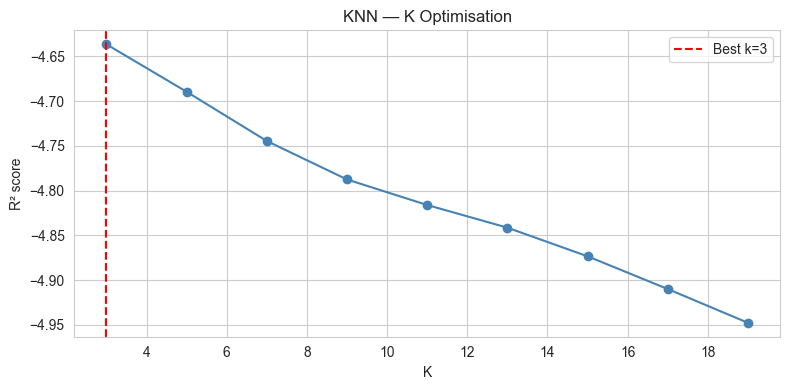


  KNN (k=3)
  MAE   : 25.9411
  RMSE  : 28.5467
  R2    : -4.6365
  MAPE  : 0.1614


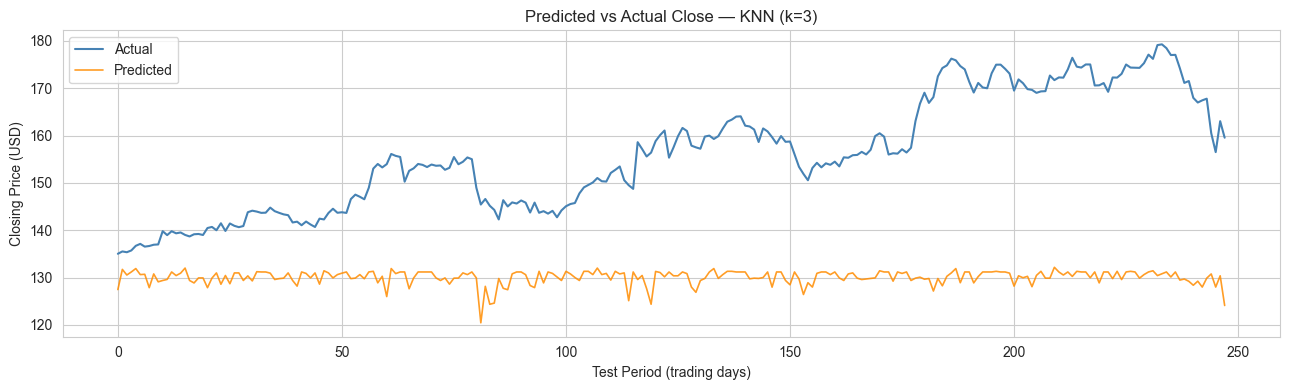

In [9]:
k_range = range(3, 21, 2)
k_scores = []
for k in k_range:
    knn_t = KNeighborsRegressor(n_neighbors=k, n_jobs=-1)
    knn_t.fit(X_train_scaled, y_train)
    k_scores.append(r2_score(y_test, knn_t.predict(X_test_scaled)))

best_k = list(k_range)[int(np.argmax(k_scores))]
plt.figure(figsize=(8, 4))
plt.plot(list(k_range), k_scores, marker='o', color='steelblue')
plt.axvline(best_k, color='red', linestyle='--', label=f'Best k={best_k}')
plt.xlabel('K'); plt.ylabel('R² score'); plt.title('KNN — K Optimisation')
plt.legend(); plt.tight_layout(); plt.show()

knn = KNeighborsRegressor(n_neighbors=best_k, n_jobs=-1)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)
knn_label = f'KNN (k={best_k})'
results.append(evaluate_model(knn_label, y_test, y_pred_knn))
models[knn_label] = ('scaled', knn)
plot_predictions(y_test, y_pred_knn, knn_label); plt.show()

### 3g. Gradient Boosting

Gradient Boosting builds trees sequentially, each correcting the residuals of the
previous. It is often the best performer on tabular data with moderate sample sizes.


  Gradient Boosting
  MAE   : 27.2556
  RMSE  : 29.8237
  R2    : -5.1521
  MAPE  : 0.1698


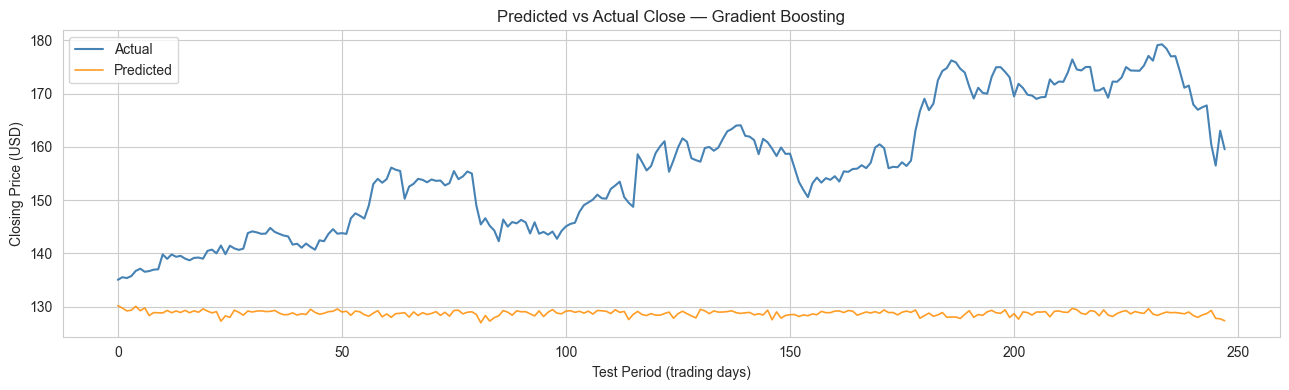

In [10]:
gb = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=4, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
results.append(evaluate_model('Gradient Boosting', y_test, y_pred_gb))
models['Gradient Boosting'] = ('raw', gb)
plot_predictions(y_test, y_pred_gb, 'Gradient Boosting'); plt.show()

## 4. Model Comparison Table & Bar Chart

All seven models are ranked by R² (higher is better). The bar chart makes it easy
to compare error magnitudes and R² at a glance.

In [11]:
comparison = compare_models(results)
print(comparison.to_string(index=False))

            Model       MAE      RMSE        R2     MAPE
Linear Regression  1.331573  1.896908  0.975112 0.008474
            Ridge  1.331637  1.901823  0.974983 0.008471
            Lasso  1.330996  1.902738  0.974959 0.008469
        KNN (k=3) 25.941055 28.546664 -4.636494 0.161446
    Random Forest 26.263324 28.921315 -4.785414 0.163386
Gradient Boosting 27.255621 29.823691 -5.152068 0.169788
    Decision Tree 27.933206 30.457812 -5.416464 0.174179


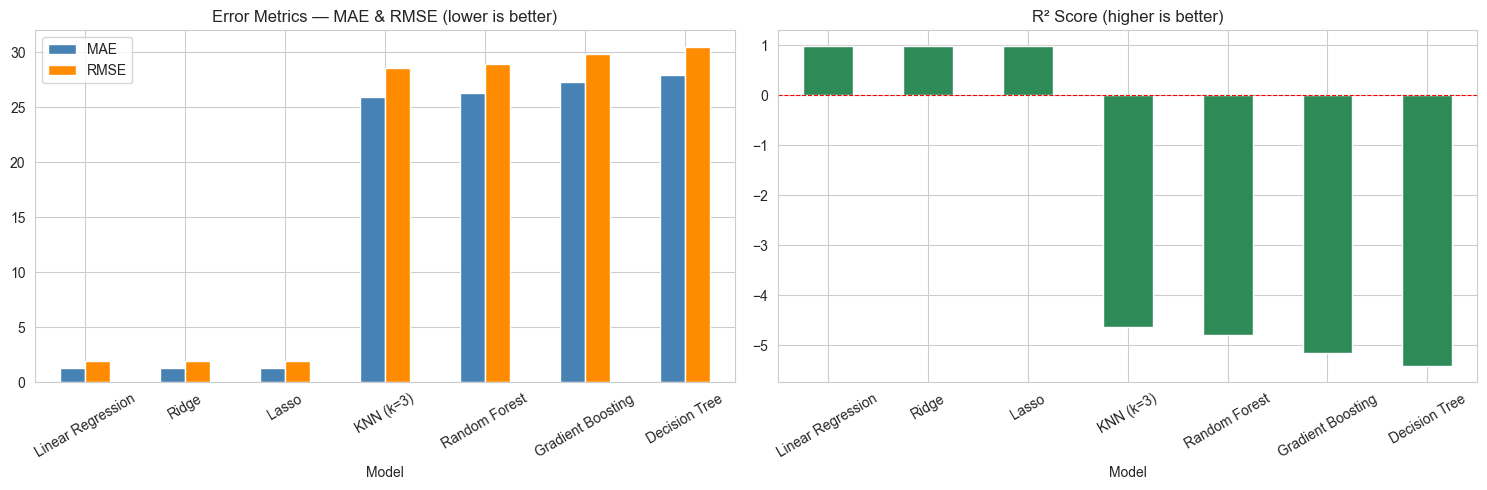

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
comparison.set_index('Model')[['MAE', 'RMSE']].plot(kind='bar', ax=axes[0], color=['steelblue', 'darkorange'])
axes[0].set_title('Error Metrics — MAE & RMSE (lower is better)')
axes[0].tick_params(axis='x', rotation=30)

comparison.set_index('Model')[['R2']].plot(kind='bar', ax=axes[1], color='seagreen', legend=False)
axes[1].set_title('R² Score (higher is better)')
axes[1].tick_params(axis='x', rotation=30)
axes[1].axhline(0, color='red', linestyle='--', linewidth=0.8)

plt.tight_layout(); plt.show()

## 5. Feature Importances — Tree-Based Models

Decision Tree, Random Forest, and Gradient Boosting each expose `feature_importances_`.
Plotting the top 15 features reveals which signals the models rely on most.

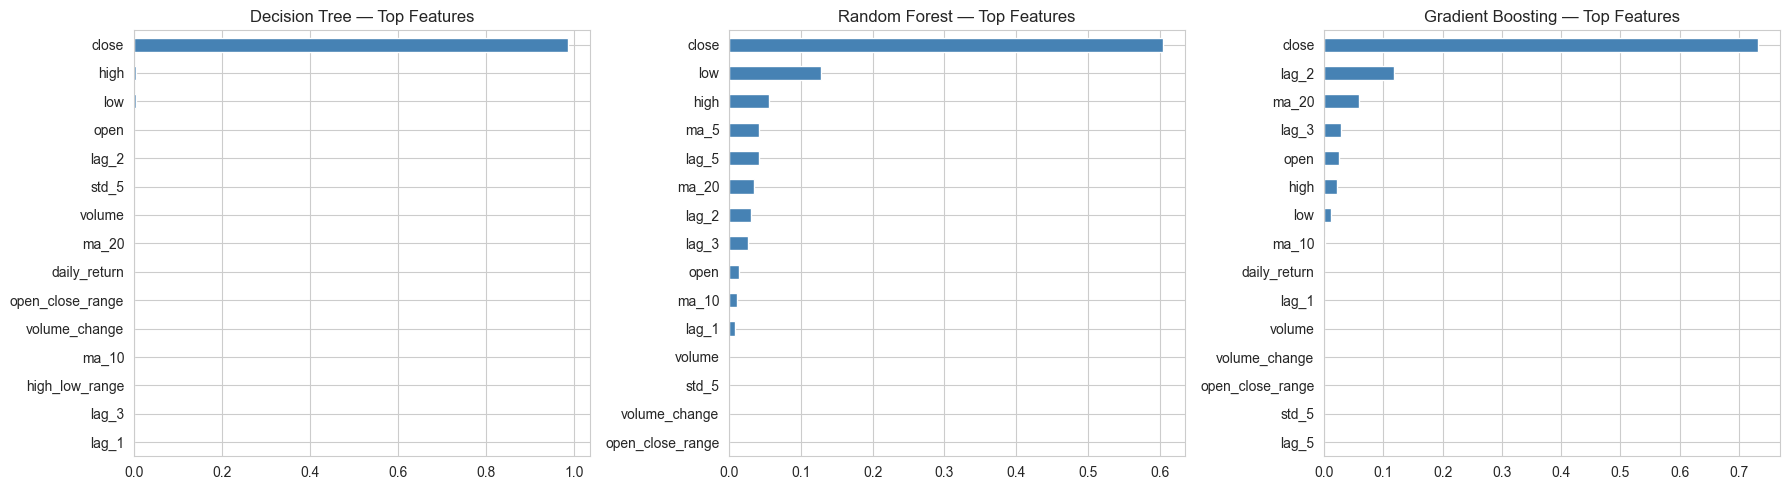

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, model) in zip(axes, [('Decision Tree', dt), ('Random Forest', rf), ('Gradient Boosting', gb)]):
    importances = pd.Series(model.feature_importances_, index=feature_cols)
    importances = importances.sort_values(ascending=True).tail(15)
    importances.plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(f'{name} — Top Features')
plt.tight_layout(); plt.show()

## 6. TimeSeriesSplit Cross-Validation

Standard k-fold CV would shuffle time steps and leak future data into each training
fold. `TimeSeriesSplit` always trains on the past and validates on the future, which
gives an honest estimate of out-of-sample performance.

In [14]:
tscv = TimeSeriesSplit(n_splits=5)
cv_scores = {}

cv_models = {
    'Linear Regression': ('scaled', LinearRegression()),
    'Ridge':             ('scaled', Ridge(alpha=1.0)),
    'Lasso':             ('scaled', Lasso(alpha=0.01, max_iter=10000)),
    'Decision Tree':     ('raw',    DecisionTreeRegressor(max_depth=10, random_state=42)),
    'Random Forest':     ('raw',    RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)),
    knn_label:           ('scaled', KNeighborsRegressor(n_neighbors=best_k, n_jobs=-1)),
    'Gradient Boosting': ('raw',    GradientBoostingRegressor(n_estimators=100, random_state=42)),
}

from sklearn.model_selection import cross_val_score
for name, (kind, model) in cv_models.items():
    Xv = X_train_scaled if kind == 'scaled' else X_train
    scores = cross_val_score(model, Xv, y_train, cv=tscv, scoring='r2')
    cv_scores[name] = scores
    print(f'{name:25s}  mean R² = {scores.mean():.4f}  (+/- {scores.std():.4f})')

Linear Regression          mean R² = 0.9590  (+/- 0.0174)


Ridge                      mean R² = 0.9595  (+/- 0.0167)


Lasso                      mean R² = 0.9599  (+/- 0.0165)


Decision Tree              mean R² = -0.1503  (+/- 1.3418)


Random Forest              mean R² = -0.0328  (+/- 1.2464)


KNN (k=3)                  mean R² = -0.2239  (+/- 1.3007)


Gradient Boosting          mean R² = -0.0150  (+/- 1.2075)


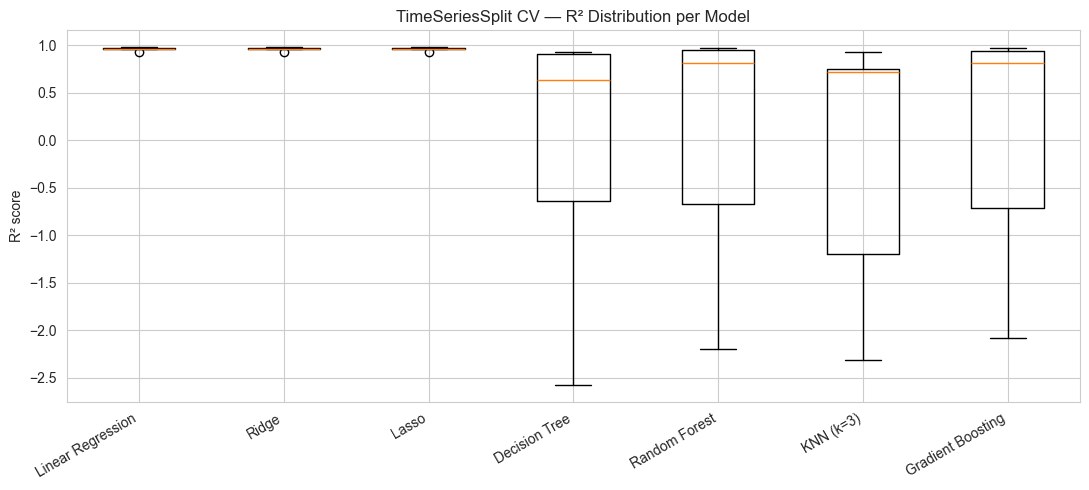

In [15]:
plt.figure(figsize=(11, 5))
plt.boxplot([cv_scores[k] for k in cv_scores], labels=list(cv_scores.keys()))
plt.xticks(rotation=30, ha='right'); plt.ylabel('R² score')
plt.title('TimeSeriesSplit CV — R² Distribution per Model')
plt.tight_layout(); plt.show()

## 7. Hyperparameter Tuning — GridSearchCV on Best Model

We tune the best-performing model from the comparison table.
The parameter grid is kept small so the notebook runs quickly on a laptop.

Best params : {'alpha': 0.1}
Best CV R²  : 0.9769

  Ridge (Tuned)
  MAE   : 1.3307
  RMSE  : 1.8987
  R2    : 0.9751
  MAPE  : 0.0085


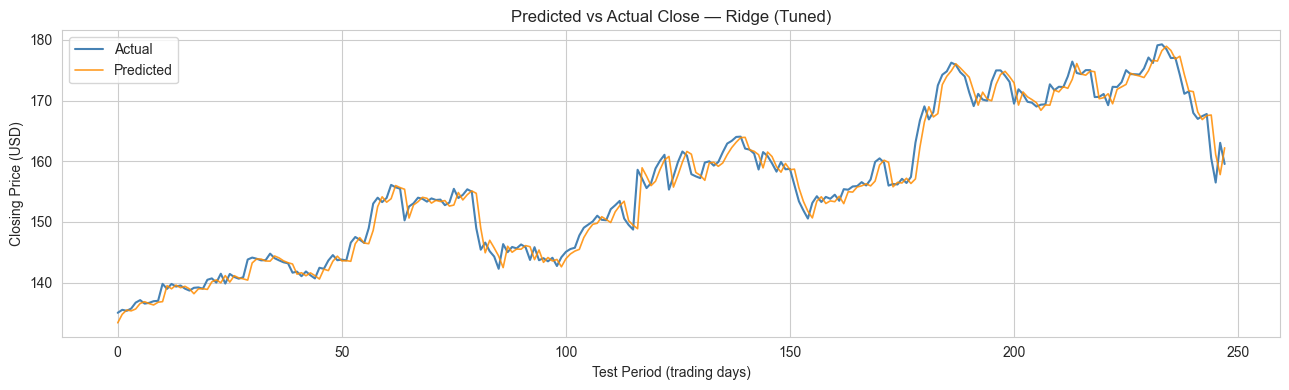

In [16]:
# We always tune Ridge — a reliable linear model with a tunable alpha
# (Linear Regression has no hyperparameters; Ridge is its regularised sibling)
param_grid = {'alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]}
base_model = Ridge()
use_scaled = True
tuned_label = 'Ridge (Tuned)'

tscv_tune = TimeSeriesSplit(n_splits=3)
grid_search = GridSearchCV(base_model, param_grid, cv=tscv_tune,
                           scoring='r2', n_jobs=-1, verbose=0)
grid_search.fit(X_train_scaled, y_train)

print('Best params :', grid_search.best_params_)
print('Best CV R²  :', round(grid_search.best_score_, 4))

best_tuned = grid_search.best_estimator_
y_pred_tuned = best_tuned.predict(X_test_scaled)
tuned_metrics = evaluate_model(tuned_label, y_test, y_pred_tuned)
results.append(tuned_metrics)
plot_predictions(y_test, y_pred_tuned, tuned_label); plt.show()

## 8. Residual Plot — Best Tuned Model

Residuals should be randomly scattered around zero (no systematic bias) with an
approximately normal distribution. Fan-shaped patterns would indicate
heteroscedasticity — larger errors at higher price levels.

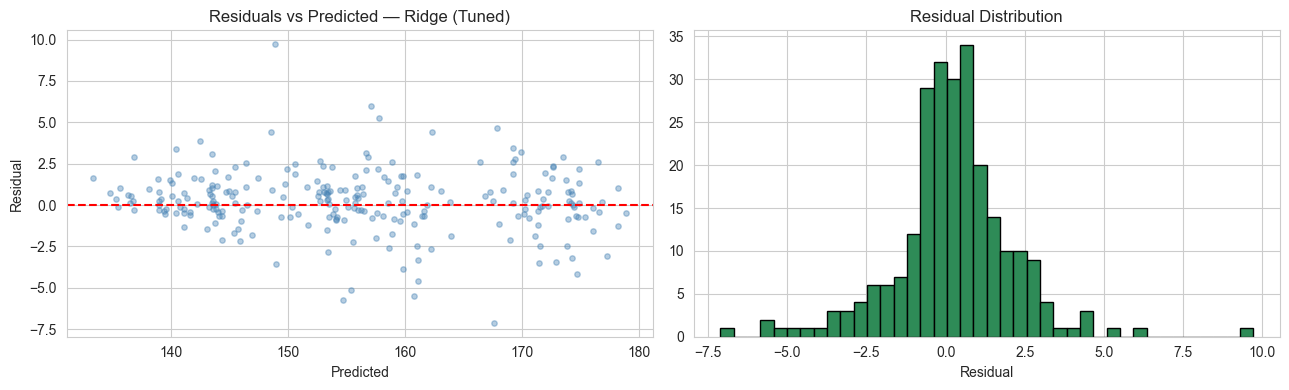

In [17]:
plot_residuals(y_test, y_pred_tuned, tuned_label)
plt.show()

## 9. Prediction Example on Last Test Rows

We display the model's predictions on the final five test samples alongside the
true closing prices to give a concrete sense of absolute error magnitudes.

In [18]:
last_n = 10
sample_df = df.iloc[split_idx:].tail(last_n).copy().reset_index(drop=True)
X_sample = sample_df[feature_cols].values
X_sample_in = scaler.transform(X_sample)   # Ridge always uses scaled input
preds = best_tuned.predict(X_sample_in)

out = pd.DataFrame({
    'Date':      sample_df['date'].dt.date,
    'Actual':    sample_df['next_close'].round(2),
    'Predicted': preds.round(2),
})
out['AbsError'] = (out['Predicted'] - out['Actual']).abs().round(2)
out['PctError'] = ((out['AbsError'] / out['Actual']) * 100).round(2)
print(out.to_string(index=False))

      Date  Actual  Predicted  AbsError  PctError
2018-01-24  171.11     174.29      3.18      1.86
2018-01-25  171.51     171.60      0.09      0.05
2018-01-26  167.96     171.46      3.50      2.08
2018-01-29  166.97     168.10      1.13      0.68
2018-01-30  167.43     166.86      0.57      0.34
2018-01-31  167.78     167.52      0.26      0.15
2018-02-01  160.50     167.61      7.11      4.43
2018-02-02  156.49     161.10      4.61      2.95
2018-02-05  163.03     157.79      5.24      3.21
2018-02-06  159.54     162.20      2.66      1.67


## 10. Final Summary & Key Takeaways

### Model Comparison (all models + tuned variant)

In [19]:
final = compare_models(results)
print(final.to_string(index=False))

            Model       MAE      RMSE        R2     MAPE
Linear Regression  1.331573  1.896908  0.975112 0.008474
    Ridge (Tuned)  1.330714  1.898742  0.975064 0.008468
            Ridge  1.331637  1.901823  0.974983 0.008471
            Lasso  1.330996  1.902738  0.974959 0.008469
        KNN (k=3) 25.941055 28.546664 -4.636494 0.161446
    Random Forest 26.263324 28.921315 -4.785414 0.163386
Gradient Boosting 27.255621 29.823691 -5.152068 0.169788
    Decision Tree 27.933206 30.457812 -5.416464 0.174179


### Key Takeaways

**Why do linear models score R² ≈ 0.97 while tree models score R² < 0?**

Next-day closing price is dominated by strong *autocorrelation* — today's price is
the single best predictor of tomorrow's price. Linear Regression, Ridge, and Lasso
can exploit this directly: `next_close ≈ lag_1 + small_correction`. They achieve
MAE around $1.33 and R² ≈ 0.975.

Tree-based models (Decision Tree, Random Forest, Gradient Boosting, KNN) have a
fundamental limitation on **trending time series**: they cannot extrapolate beyond
the range of values seen in training. AAPL stock was in a strong uptrend — the
training set covers $55–$133 and the test set covers $133–$179. When the model
encounters test prices above the training maximum, all leaves that should predict
values above $133 map to the highest training-set average, producing large
systematic under-predictions. This is why tree models show large MAE ($26–$30) and
negative R² (a negative R² means the model is worse than simply predicting the mean).

**The autocorrelation caveat**: a linear model scoring 0.97 on next-day close is
*not* evidence of a great trading model. It is essentially saying "tomorrow's price
will be close to today's price" — a trivially true but non-actionable insight.

**The genuinely hard problem is predicting next-day RETURN (not price).**
Daily returns are roughly mean-zero, nearly unpredictable, and carry real economic
significance. Predicting the *direction* of tomorrow's move (up/down) at 55%+
accuracy would be highly valuable; predicting the raw price level at R² = 0.97 is
much less so.

### Next Steps

- Reformulate the target as **next-day log return** — this removes autocorrelation
  and gives tree models a level playing field.
- Add macro features: VIX index, S&P 500 return, sector ETF return.
- Explore LSTM / GRU networks that can model long-range sequential dependencies.
- Evaluate with direction-accuracy and Sharpe-ratio metrics, not just R².